# ResNet18 on CIFAR-100 (PyTorch)

Experimenting with ResNet18 architecture on the CIFAR-100 dataset as part of a comparative study of CNN architectures.

- **Framework:** PyTorch
- **Dataset:** CIFAR-100 (60,000 images, 100 classes)
- **Optimizer:** Adam | **Loss:** CrossEntropyLoss | **Epochs:** 10
- **Hardware:** GPU (Google Colab T4)

## 1. Importing Libraries

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, random_split
from torchvision.utils import make_grid
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## 2. Data Preprocessing
Applying data augmentation on training set (RandomCrop, RandomHorizontalFlip) to improve generalization.
Test set uses only normalization — no augmentation.
Pixel values normalized to [-1, 1] range using mean and std of 0.5 per channel.

In [2]:
data_statistics = ((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))

train_transforms = transforms.Compose([
    transforms.RandomCrop(32, padding=4, padding_mode='reflect'),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(*data_statistics, inplace=True)
])

test_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(*data_statistics, inplace=True)
])

## 3. Loading CIFAR-10 and Creating DataLoaders
Splitting training data into 80% train and 20% validation sets.
Batch size: 64, num_workers: 2 (optimized for GPU throughput).

In [3]:
dataset = torchvision.datasets.CIFAR100(root='data/', download=True, transform=train_transforms)
test_dataset = torchvision.datasets.CIFAR100(root='data/', download=True, train=False, transform=test_transforms)

val_ratio = 0.2
train_len = int((1 - val_ratio) * len(dataset))
val_len = len(dataset) - train_len
train_dataset, val_dataset = random_split(dataset, [train_len, val_len])

batch_size = 64

train_dl = DataLoader(train_dataset, batch_size, shuffle=True, pin_memory=True, num_workers=2, persistent_workers=True)
val_dl = DataLoader(val_dataset, batch_size, shuffle=False, pin_memory=True, num_workers=2, persistent_workers=True)
test_dl = DataLoader(test_dataset, batch_size, shuffle=False, pin_memory=True, num_workers=2, persistent_workers=True)

print(f"Train size: {train_len} | Val size: {val_len} | Test size: {len(test_dataset)}")
print(f"Dataloaders initialized with batch size: {batch_size}")

Train size: 40000 | Val size: 10000 | Test size: 10000
Dataloaders initialized with batch size: 64


## 4. Data Exploration
Visualizing a batch of training images to verify data loading and augmentation pipeline.

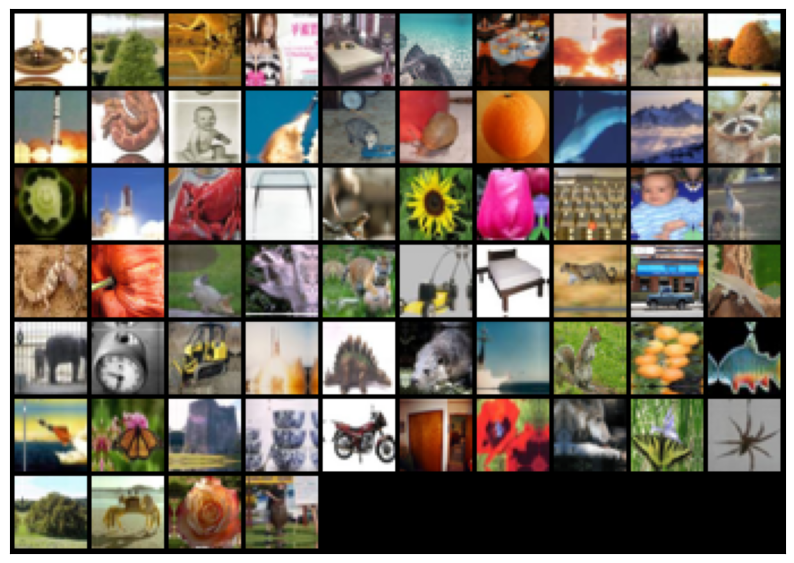

In [4]:
def denormalize(images, means, std_devs):
    dev = images.device
    means = torch.tensor(means).reshape(1, 3, 1, 1).to(dev)
    std_devs = torch.tensor(std_devs).reshape(1, 3, 1, 1).to(dev)
    return images * std_devs + means

def show_batch(dl):
    for images, labels in dl:
        fig, ax = plt.subplots(figsize=(10, 10))
        images = denormalize(images, *data_statistics)
        grid = make_grid(images, nrow=10).cpu().permute(1, 2, 0)
        ax.imshow(grid)
        ax.set_xticks([])
        ax.set_yticks([])
        break

show_batch(train_dl)

## 5. Device Utilities
Helper functions and wrapper class to move data and models to GPU automatically.

In [5]:
def to_device(entity, device):
    if isinstance(entity, (list, tuple)):
        return [to_device(elem, device) for elem in entity]
    if hasattr(entity, 'to'):
        return entity.to(device, non_blocking=True)
    return entity

class DeviceDataLoader():
    """Wrapper around DataLoader to transfer batches to specified device."""
    def __init__(self, dataloader, device):
        self.dl = dataloader
        self.device = device

    def __iter__(self):
        for b in self.dl:
            yield to_device(b, self.device)

    def __len__(self):
        return len(self.dl)

train_dl = DeviceDataLoader(train_dl, device)
val_dl = DeviceDataLoader(val_dl, device)
test_dl = DeviceDataLoader(test_dl, device)
print(f"Data wrappers initialized on: {device}")

Data wrappers initialized on: cuda


## 6. Model Architecture — ResNet18
Using the standard ResNet18 architecture from torchvision.models.
The final fully connected layer is modified to output 100
classes for CIFAR-10.

| Component | Details |
|-----------|---------|
| Base Model | ResNet18 (torchvision.models) |
| Pretrained | False (trained from scratch) |
| Final Layer | Linear(512, 10) — modified for CIFAR-100 |
| Total Output Classes | 100 |

- **Activation:** ReLU
- **Regularization:** BatchNorm2d (built into ResNet18)

In [6]:
model = models.resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, 100)
model = to_device(model, device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total Trainable Parameters: {total_params:,}")

Total Trainable Parameters: 11,227,812


## 7. Training Utilities
- `accuracy()` computes batch-level classification accuracy
- `evaluate()` runs the model in eval mode over a dataloader
- `train()` runs the full training loop with OneCycleLR scheduler and gradient clipping

In [7]:
def accuracy(logits, labels):
    _, predClassId = torch.max(logits, dim=1)
    return torch.tensor(torch.sum(predClassId == labels).item() / len(logits))

def evaluate(model, dl, loss_func):
    batch_losses, batch_accs = [], []
    model.eval()
    for images, labels in dl:
        with torch.no_grad():
            logits = model(images)
        batch_losses.append(loss_func(logits, labels))
        batch_accs.append(accuracy(logits, labels))
    epoch_avg_loss = torch.stack(batch_losses).mean().item()
    epoch_avg_acc = torch.stack(batch_accs).mean().item()
    return epoch_avg_loss, epoch_avg_acc

def train(model, train_dl, val_dl, epochs, max_lr, loss_func, optim):
    optimizer = optim(model.parameters(), max_lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr, epochs=epochs, steps_per_epoch=len(train_dl))

    results = []
    lrs = []
    for epoch in range(epochs):
        model.train()
        train_losses = []
        for images, labels in train_dl:
            logits = model(images)
            loss = loss_func(logits, labels)
            train_losses.append(loss.detach())

            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 0.1)
            optimizer.step()
            optimizer.zero_grad()

            lrs.append(optimizer.param_groups[0]["lr"])
            scheduler.step()

        epoch_train_loss = torch.stack(train_losses).mean().item()

        model.eval()
        batch_losses, batch_accs = [], []
        for images, labels in val_dl:
            with torch.no_grad():
                logits = model(images)
            batch_losses.append(loss_func(logits, labels))
            batch_accs.append(accuracy(logits, labels))

        epoch_avg_loss = torch.stack(batch_losses).mean().item()
        epoch_avg_acc = torch.stack(batch_accs).mean().item()

        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_avg_loss:.4f} | Val Acc: {epoch_avg_acc:.4f}")

        results.append({
            'avg_valid_loss': epoch_avg_loss,
            'avg_valid_acc': epoch_avg_acc,
            'avg_train_loss': epoch_train_loss
        })

    return results, lrs

## 8. Training
Training ResNet18 for 10 epochs using Adam optimizer with OneCycleLR scheduler and gradient clipping (max_norm=0.1).
Weight decay of 1e-4 applied for regularization.

In [8]:
epochs = 10
max_lr = 1e-2
loss_func = nn.functional.cross_entropy
optim = torch.optim.Adam

start_time = time.time()
results, lrs = train(model, train_dl, val_dl, epochs, max_lr, loss_func, optim)
end_time = time.time()

training_time = end_time - start_time
print(f"\nTraining complete. Training Time: {training_time:.2f} seconds")

Epoch [1/10] | Train Loss: 3.9930 | Val Loss: 4.1308 | Val Acc: 0.0735
Epoch [2/10] | Train Loss: 3.8411 | Val Loss: 3.7841 | Val Acc: 0.1164
Epoch [3/10] | Train Loss: 3.6819 | Val Loss: 3.8434 | Val Acc: 0.1005
Epoch [4/10] | Train Loss: 3.5393 | Val Loss: 3.5558 | Val Acc: 0.1438
Epoch [5/10] | Train Loss: 3.4321 | Val Loss: 3.5023 | Val Acc: 0.1534
Epoch [6/10] | Train Loss: 3.3303 | Val Loss: 3.2515 | Val Acc: 0.2033
Epoch [7/10] | Train Loss: 3.1950 | Val Loss: 3.1311 | Val Acc: 0.2289
Epoch [8/10] | Train Loss: 3.0643 | Val Loss: 2.9982 | Val Acc: 0.2500
Epoch [9/10] | Train Loss: 2.9237 | Val Loss: 2.8467 | Val Acc: 0.2812
Epoch [10/10] | Train Loss: 2.8284 | Val Loss: 2.8064 | Val Acc: 0.2845

Training complete. Training Time: 305.75 seconds


## 9. Training Curves
Plotting validation accuracy, train/val loss, and learning rate schedule across epochs.

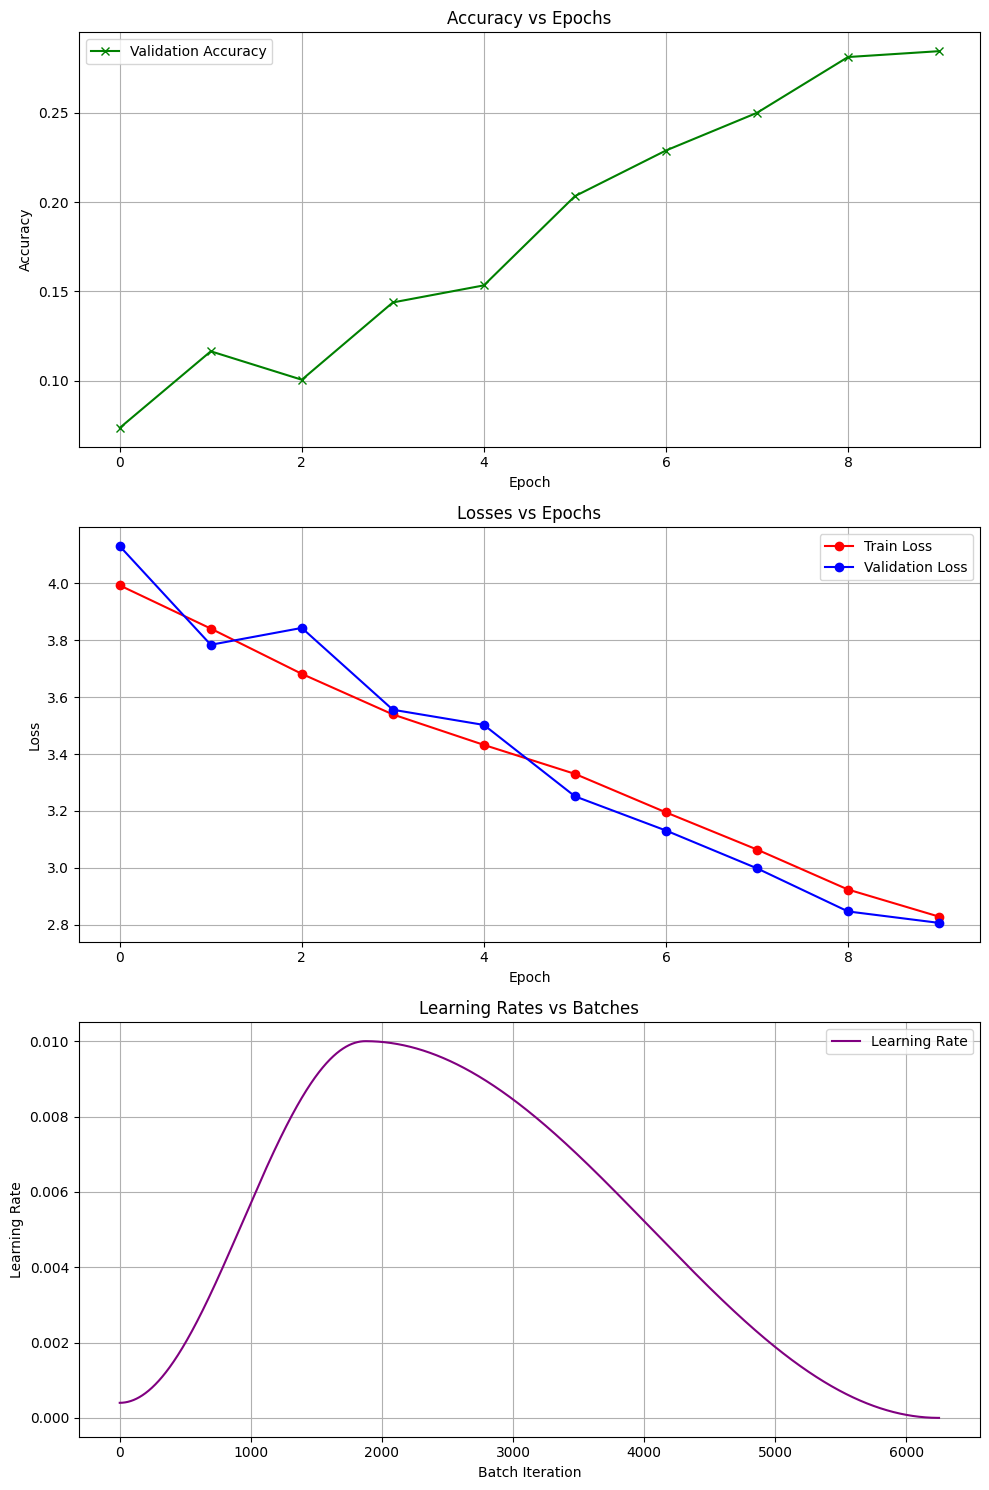

In [9]:
def plot_metrics(results, lrs):
    fig, axes = plt.subplots(3, 1, figsize=(10, 15))

    val_accs = [r['avg_valid_acc'] for r in results]
    axes[0].plot(val_accs, '-x', color='green', label='Validation Accuracy')
    axes[0].set_title('Accuracy vs Epochs')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True)

    train_losses = [r['avg_train_loss'] for r in results]
    val_losses = [r['avg_valid_loss'] for r in results]
    axes[1].plot(train_losses, '-o', color='red', label='Train Loss')
    axes[1].plot(val_losses, '-o', color='blue', label='Validation Loss')
    axes[1].set_title('Losses vs Epochs')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True)

    axes[2].plot(lrs, color='purple', label='Learning Rate')
    axes[2].set_title('Learning Rates vs Batches')
    axes[2].set_xlabel('Batch Iteration')
    axes[2].set_ylabel('Learning Rate')
    axes[2].legend()
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()

plot_metrics(results, lrs)

## 10. Saving and Evaluating the Model
Saving trained weights, then verifying the save/load pipeline by evaluating both the original and reloaded model.
Both should produce identical test accuracy.

In [10]:
_, test_acc = evaluate(model, test_dl, loss_func)
print(f"Original model test accuracy: {test_acc:.4f}")

torch.save(model.state_dict(), 'cifar100_resnet18.pth')

model2 = models.resnet18(weights=None)
model2.fc = nn.Linear(model2.fc.in_features, 100)
model2 = to_device(model2, device)
model2.load_state_dict(torch.load('cifar100_resnet18.pth', weights_only=True))
_, test_acc2 = evaluate(model2, test_dl, loss_func)
print(f"Reloaded model test accuracy: {test_acc2:.4f}")

Original model test accuracy: 0.3125
Reloaded model test accuracy: 0.3125


## 11. Results Summary

| Metric | Value |
|--------|-------|
| Test Accuracy | *31.25%* |
| Trainable Parameters | *11,227,812* |
| Training Time | *305.75 seconds(5.09583333 minutes)* |
| Hardware | GPU (Google Colab T4) |
| Epochs | 10 |
| Optimizer | Adam + OneCycleLR |

**Observation:** The learning rate graph follows the OneCycleLR pattern — 
rising aggressively to 0.01 until around epoch 3, causing 
large unstable updates and flat or dropping accuracy in 
early epochs, then annealing to near zero by epoch 9, 
which corresponds to the consistent accuracy improvement 
seen in later epochs.

ResNet18 achieves 31.25% test accuracy on CIFAR-100,
underperforming the Baseline CNN (39.05%) despite having
significantly more parameters (11,227,812 vs 620,810).

Accuracy dips between epochs 0 and 2 before improving
consistently from epoch 2 onward. This early instability
is caused by the OneCycleLR warmup phase aggressively
increasing the learning rate, causing the model to
overshoot temporarily. From epoch 6 onward accuracy
improves sharply, suggesting the model was still learning
at epoch 9 and more epochs would improve results further.

Validation loss is higher than train loss in early epochs
due to the same warmup instability, but from epoch 6
onward both losses decrease together and val loss drops
below train loss — expected behavior due to Dropout being
disabled during evaluation.

ResNet18 underperforms the Baseline CNN on CIFAR-100 for
the same reason as CIFAR-10 — its architecture was designed
for large 224x224 images. On 32x32 images the aggressive
downsampling loses critical spatial information, which is
even more damaging on CIFAR-100 where distinguishing 100
fine-grained classes requires preserving fine spatial details.as removing the initial
MaxPool layer would likely improve performance on small images.